In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data  = np.array([[40,20],
                 [55,30],
                 [70,60],
                 [50,35],
                 [45,40],
                 [62,75],
                 [45,30],
                 [68,80],
                 [80,70],
                 [75,90]]) 

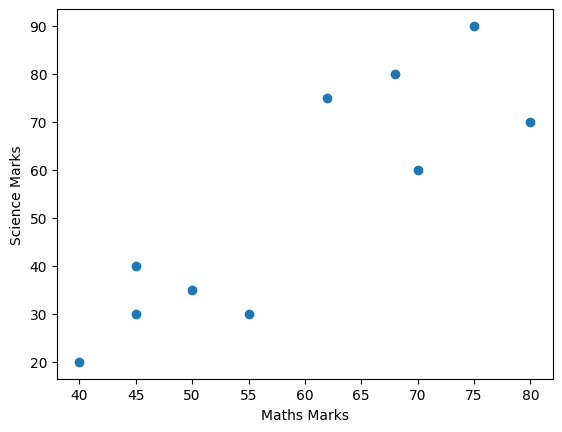

In [4]:
plt.scatter(data[:,0],data[:,1])
plt.xlabel('Maths Marks')
plt.ylabel('Science Marks')
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
print(scaled_data)

[[-1.43299332 -1.39951173]
 [-0.3016828  -0.97541727]
 [ 0.82962771  0.29686613]
 [-0.67878631 -0.76337004]
 [-1.05588981 -0.5513228 ]
 [ 0.2262621   0.93300782]
 [-1.05588981 -0.97541727]
 [ 0.67878631  1.14505506]
 [ 1.58383472  0.72096059]
 [ 1.20673122  1.56914952]]


In [7]:
# PCA analysis eka use kiriima

from sklearn.decomposition import PCA

In [15]:
pca = PCA(n_components = 1)
pca.fit(scaled_data)

PCA(n_components=1)

In [16]:
# variance deka labeee
pca.explained_variance_

array([2.07778406])

In [17]:
# pahatha paridi ratio ekak ganna puluwan. enam kochchara pramanayak data harahaa gihinda baliimata
pca.explained_variance_ratio_

array([0.93500282])

In [18]:
pca_scaled_data = pca.transform(scaled_data)

In [20]:
scaled_data.shape

(10, 2)

In [21]:
pca_scaled_data.shape

(10, 1)

In [22]:
pca_scaled_data = pca.inverse_transform(pca_scaled_data)

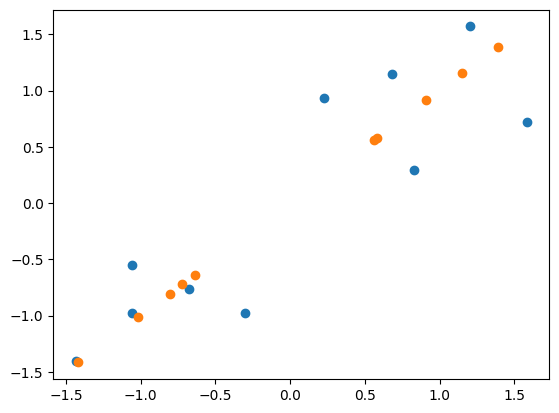

In [23]:
# mehiidii kalin thibba data saha eewaa dimention gana adukarama labena sarala reekaawa wage eka laba gatha haka
plt.scatter(scaled_data[:,0],scaled_data[:,1])
plt.scatter(pca_scaled_data[:,0],pca_scaled_data[:,1])

In [24]:
# PCA for visualization

from sklearn.datasets import load_digits
digits = load_digits()

In [25]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [27]:
digits.data.shape

(1797, 64)

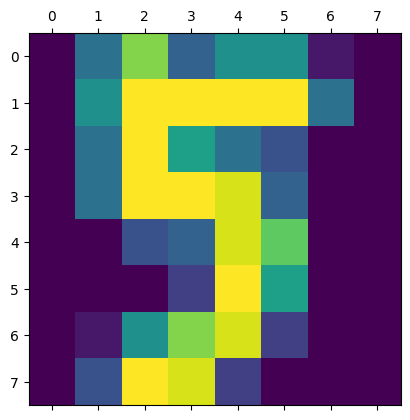

In [35]:
# data set eke eka data point ekaka image ekak lesa penwiima eyata hethuwa thama mehi columns 64 k thibe. enam dimentions 64 ki.

import matplotlib.pyplot as plt
plt.matshow(digits.images[33])
plt.show()

In [37]:
# ena image eka hariyatama eeka da bailiima
digits.target[33]

np.int64(5)

In [38]:
# demention gana adu karaganiima
# demention 64 eka demention 10 kata adu kiriima

from sklearn.decomposition import PCA
pca = PCA(n_components = 10)
new_digits = pca.fit_transform(digits.data)

In [39]:
new_digits.shape

(1797, 10)

In [40]:
digits.data.shape

(1797, 64)

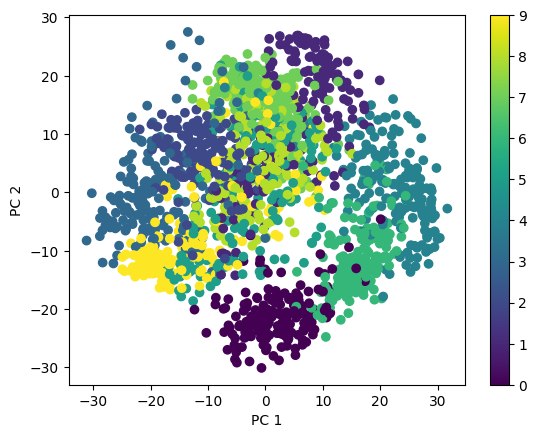

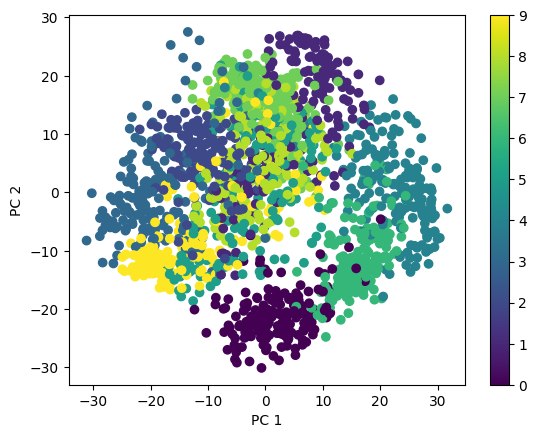

In [44]:
# pahatha paridi 0 sita 9 dakwaa ilakkm walata adala classes walata adala data pont tika penwiya haka
# c = digits.target magin class walata wena wenama paata laba dee.
# plt.colorbar() nagin color palet eka laba dee.

import matplotlib.pyplot as plt
plt.scatter(new_digits[:,0], new_digits[:,1],c = digits.target)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.colorbar()
plt.show(0)

In [45]:
# PCA for speeup models

from sklearn.datasets import load_digits
import numpy as np


In [50]:
digits = load_digits()

In [51]:
digits.data.shape

(1797, 64)

In [55]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
new_data = sc.fit_transform(digits.data)

In [69]:
from sklearn.decomposition import PCA
pca = PCA(n_components =10)
new_data_pca = pca.fit_transform(new_data)

In [70]:
new_data_pca.shape

(1797, 10)

In [75]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(new_data_pca, digits.target , test_size = 0.2 , random_state = 42)


In [76]:
x_test.shape

(360, 10)

In [79]:
x_train.shape

(1437, 10)

In [80]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver = 'lbfgs', max_iter = 1000)

import time
start = time.time()
model.fit(x_train , y_train)
end = time.time()

print((end - start)*1000)

103.8966178894043


In [81]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy_score(y_test,y_pred)

0.8972222222222223